# Problema 2 – Regresión: Estimación de Edad a partir de Imágenes Faciales
**Universidad EAFIT – Introducción a la Inteligencia Artificial (2026-01)**

Este notebook desarrolla el ciclo completo de un proyecto de Deep Learning supervisado para
estimar la **edad** de una persona a partir de imágenes faciales usando una Red Neuronal Convolucional (CNN).

**Dataset:** [arashnic/faces-age-detection-dataset](https://www.kaggle.com/datasets/arashnic/faces-age-detection-dataset)

---
**Contenido:**
1. Análisis Preliminar del Problema
2. Análisis Exploratorio de Datos (EDA)
3. Procesamiento de Datos
4. Entrenamiento del Modelo CNN para Regresión
5. Prueba con Muestra Artificial


## 0. Importación de Librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os, glob, random
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print("Librerías importadas correctamente.")
print(f"Semilla global: SEED = {SEED}")

Librerías importadas correctamente.
Semilla global: SEED = 42


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

BASE_PATH    = "/content/drive/MyDrive/workshop_2/regresion/data/"
ZIP_PATH     = BASE_PATH + "faces-age-detection-dataset.zip"
EXTRACT_PATH = "/content/data/"

if not os.path.exists(EXTRACT_PATH):
    os.makedirs(EXTRACT_PATH, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("Dataset descomprimido.")
else:
    print("Dataset ya estaba descomprimido.")

#Construcción dataframe para regresión
part3_path = os.path.join(EXTRACT_PATH, "faces_02", "part3")

records = []
for fname in os.listdir(part3_path):
    if fname.lower().endswith((".jpg", ".png", ".jpeg")):
        age = int(fname.split("_")[0])
        records.append({
            "filename": fname,
            "filepath": os.path.join(part3_path, fname),
            "age": age
        })

df_reg = pd.DataFrame(records)

print(f"Total imagenes para regresion: {len(df_reg)}")
print(f"Rango de edades: {df_reg['age'].min()} - {df_reg['age'].max()} anios")
print(f"Edad promedio: {df_reg['age'].mean():.1f} anios")
print(df_reg.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset ya estaba descomprimido.
Total imagenes para regresion: 3250
Rango de edades: 1 - 116 anios
Edad promedio: 40.6 anios
                       filename  \
0  35_0_3_20170119201446469.jpg   
1  95_1_0_20170120230322267.jpg   
2  26_0_3_20170119180439076.jpg   
3  52_0_3_20170119200259595.jpg   
4  34_0_3_20170119200815092.jpg   

                                            filepath  age  
0  /content/data/faces_02/part3/35_0_3_2017011920...   35  
1  /content/data/faces_02/part3/95_1_0_2017012023...   95  
2  /content/data/faces_02/part3/26_0_3_2017011918...   26  
3  /content/data/faces_02/part3/52_0_3_2017011920...   52  
4  /content/data/faces_02/part3/34_0_3_2017011920...   34  


## 1. Análisis Preliminar del Problema

### 1a. ¿Por qué es un problema de regresión?

### a. Justificación como problema de regresión

Este es un problema de regresión porque la variable objetivo es la edad
del sujeto expresada en años, un valor numérico que puede tomar cualquier
entero dentro de un rango continuo. El dataset confirmó un rango de 1 a 116
años con 93 valores únicos de edad distribuidos a lo largo de ese espectro.

El modelo debe aprender a mapear los píxeles de una imagen facial a un número
real, no a una etiqueta discreta. Si el objetivo fuera agrupar en categorías
(joven, adulto, mayor), sería clasificación. Como se busca estimar la edad
exacta, es regresión.

**Variable objetivo (target):** columna `age`, edad en años (int64).
Rango: 1 – 116 años | Valores únicos: 93 | Total de muestras: 3.250

**Variables de entrada (features):** los píxeles de cada imagen facial
organizados como un tensor de dimensiones (alto × ancho × canales de color),
que la CNN procesará directamente sin extracción manual de características.

### 1b. Descripción de las características de entrada

In [ ]:
sample_paths = df_reg["filepath"].sample(5, random_state=SEED).tolist()

dimensiones = []
modos = []

print(f"Shape del dataset: {df_reg.shape}")
print(f"Columnas: {list(df_reg.columns)}")
print(f"\nPrimeras filas:")
print(df_reg.head())

print(f"\n{'Archivo':<45} {'Tamaño (ancho x alto)':<25} {'Modo de color':<15} {'Canales'}")
print("-" * 100)

for path in sample_paths:
    img = Image.open(path)
    nombre = os.path.basename(path)
    dimensiones.append(img.size)
    modos.append(img.mode)
    print(f"{nombre:<45} {str(img.size):<25} {img.mode:<15} {len(img.getbands())}")

print(f"\nDimensiones encontradas: {set(dimensiones)}")
print(f"Modos de color encontrados: {set(modos)}")

Shape del dataset: (3250, 3)
Columnas: ['filename', 'filepath', 'age']

Primeras filas:
                       filename  \
0  35_0_3_20170119201446469.jpg   
1  95_1_0_20170120230322267.jpg   
2  26_0_3_20170119180439076.jpg   
3  52_0_3_20170119200259595.jpg   
4  34_0_3_20170119200815092.jpg   

                                            filepath  age  
0  /content/data/faces_02/part3/35_0_3_2017011920...   35  
1  /content/data/faces_02/part3/95_1_0_2017012023...   95  
2  /content/data/faces_02/part3/26_0_3_2017011918...   26  
3  /content/data/faces_02/part3/52_0_3_2017011920...   52  
4  /content/data/faces_02/part3/34_0_3_2017011920...   34  

Archivo                                       Tamaño (ancho x alto)     Modo de color   Canales
----------------------------------------------------------------------------------------------------
22_1_3_20170119163211532.jpg                  (566, 359)                RGB             3
68_0_0_20170120224541303.jpg                  (456, 4

El dataset contiene 3.250 imágenes en formato JPEG organizadas en la
carpeta `faces_02/part3`. El análisis de una muestra representativa reveló
las siguientes características:

- **Espacio de color:** todas las imágenes están en modo RGB (3 canales:
  rojo, verde, azul).
- **Dimensiones:** variables entre imágenes. La muestra mostró tamaños como
  566×359, 456×445, 422×421, 450×451 y 690×353 píxeles, lo que indica que
  el dataset no tiene un tamaño estándar uniforme.
- **Total de muestras:** 3.250 imágenes con edades entre 1 y 116 años.

Dado que la CNN requiere que todas las imágenes tengan las mismas dimensiones,
se aplicará un redimensionamiento estándar a **128×128 píxeles RGB** en la
etapa de preprocesamiento. Este tamaño es un balance entre preservar
información facial relevante y mantener un costo computacional manejable
en Google Colab.

### 1c. Protocolo de adquisición y generación del dataset


El dataset publicado en Kaggle (arashnic/faces-age-detection-dataset) combina
dos fuentes distintas. La carpeta `faces/Train` corresponde al **IMFDB (Indian
Movie Face Database)**, con imágenes etiquetadas por categorías de edad (Young,
Middle, Old), útil para clasificación pero no para regresión. La carpeta
`faces_02/part3`, que es la utilizada en este proyecto, corresponde al
**UTKFace Dataset**, desarrollado por el grupo AICIP de la Universidad de
Tennessee.

**Recolección de imágenes:**
Las imágenes fueron recolectadas automáticamente de Internet mediante web
scraping de motores de búsqueda y plataformas públicas. Al no ser capturadas
en condiciones controladas, presentan alta variabilidad en pose, expresión
facial, iluminación, oclusión y resolución. Cada imagen fue filtrada para
contener exactamente un rostro.

**Detección y alineación facial:**
Las imágenes fueron procesadas con un detector de rostros automático para
localizar y recortar la región facial, y se aplicó alineación usando 68
puntos de referencia (landmarks) para normalizar la posición de ojos, nariz
y boca entre imágenes.

**Etiquetado de edad:**
La edad no fue reportada por los sujetos. Se estimó mediante el algoritmo
**DEX (Deep EXpectation of apparent age from a single image)**, una CNN
entrenada para estimar la edad aparente, cuyas predicciones fueron revisadas
y corregidas manualmente. Esto implica que las etiquetas representan la
**edad aparente** y no la edad biológica real, lo cual debe tenerse en cuenta
al interpretar los resultados del modelo.

**Codificación de metadatos:**
Toda la información está codificada en el nombre del archivo:
`[edad]_[género]_[raza]_[fecha-hora].jpg`
- `edad`: entero de 0 a 116 años
- `género`: 0 = masculino, 1 = femenino
- `raza`: 0 = blanco, 1 = negro, 2 = asiático, 3 = indio, 4 = otros

**Licencia:** CC0 Public Domain — uso libre sin restricciones.

**Sesgos conocidos:**
Al provenir de Internet, el dataset puede presentar desequilibrio en la
representación de ciertos grupos de edad, género o etnia. Las edades extremas
(mayores de 90 años) tienen muy pocas muestras, lo que puede afectar la
capacidad del modelo para predecir en esos rangos.

**Referencias:**
- Kaggle: https://www.kaggle.com/datasets/arashnic/faces-age-detection-dataset
- UTKFace original: https://susanqq.github.io/UTKFace/

## 2. Análisis Exploratorio de Datos (EDA)

### Distribución de edades en el dataset (histograma, estadísticos descriptivos).

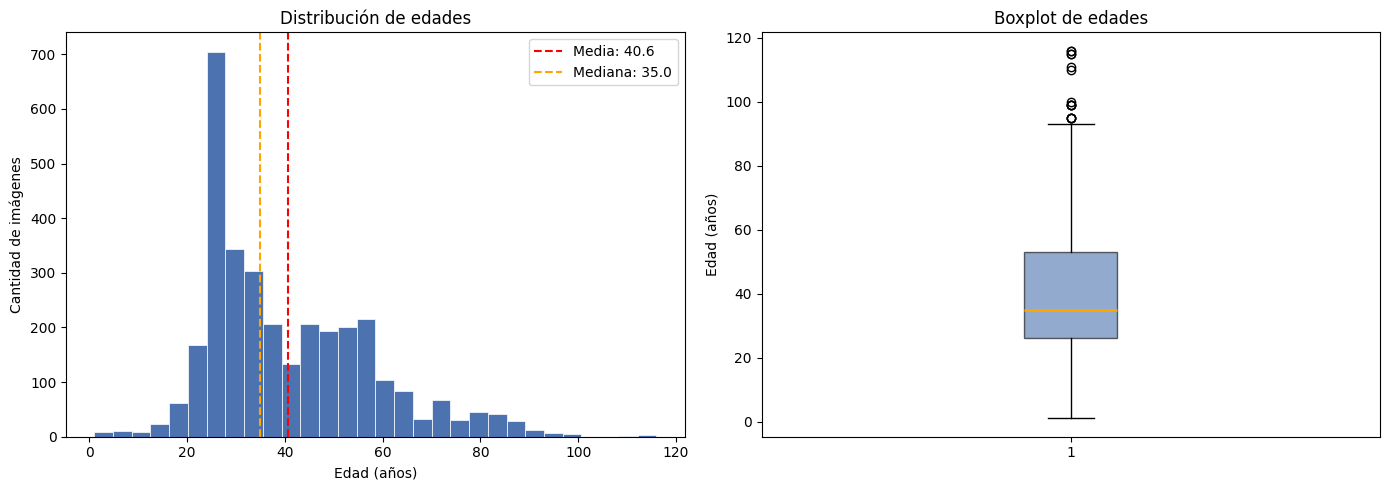

Estadísticos descriptivos de la variable objetivo (edad):
count    3250.00
mean       40.55
std        17.31
min         1.00
25%        26.00
50%        35.00
75%        53.00
90%        65.00
95%        74.00
max       116.00
Name: age, dtype: float64

Asimetría (skewness): 0.944
Curtosis (kurtosis):  0.622


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df_reg["age"], bins=30, color="#4C72B0", edgecolor="white", linewidth=0.5)
axes[0].set_title("Distribución de edades")
axes[0].set_xlabel("Edad (años)")
axes[0].set_ylabel("Cantidad de imágenes")
axes[0].axvline(df_reg["age"].mean(), color="red", linestyle="--", linewidth=1.5, label=f'Media: {df_reg["age"].mean():.1f}')
axes[0].axvline(df_reg["age"].median(), color="orange", linestyle="--", linewidth=1.5, label=f'Mediana: {df_reg["age"].median():.1f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(df_reg["age"], vert=True, patch_artist=True,
                boxprops=dict(facecolor="#4C72B0", alpha=0.6),
                medianprops=dict(color="orange", linewidth=2))
axes[1].set_title("Boxplot de edades")
axes[1].set_ylabel("Edad (años)")

plt.tight_layout()
plt.savefig("eda_distribucion_edades.png", dpi=150, bbox_inches="tight")
plt.show()

# Estadísticos descriptivos
stats = df_reg["age"].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95])
print("Estadísticos descriptivos de la variable objetivo (edad):")
print(stats.round(2))
print(f"\nAsimetría (skewness): {df_reg['age'].skew():.3f}")
print(f"Curtosis (kurtosis):  {df_reg['age'].kurt():.3f}")

**Interpretación:**

Los estadísticos descriptivos revelan que la distribución de edades presenta
las siguientes características:

- **Tendencia central:** la edad media es 40.6 años y la mediana 35 años.
  La diferencia entre ambas indica que la media es jalada hacia arriba por
  edades extremas altas, confirmado por el valor máximo de 116 años.

- **Dispersión:** la desviación estándar de 17.3 años indica alta variabilidad
  en el dataset. El 50% central de los datos se concentra entre 26 y 53 años
  (rango intercuartílico de 27 años).

- **Asimetría positiva (skewness = 0.944):** la distribución está sesgada
  hacia la derecha, es decir, hay más imágenes de personas jóvenes y adultas
  que de personas mayores. Esto significa que el modelo tendrá más ejemplos
  para aprender en el rango 20-60 años que en edades extremas.

- **Outliers:** el boxplot confirma la presencia de valores atípicos en el
  extremo superior (edades mayores a ~90 años). Valores como 110, 115 y 116
  años son probablemente casos extremos del dataset UTKFace y podrían
  introducir ruido en el entrenamiento.

- **Implicación para el modelo:** un modelo entrenado con esta distribución
  tenderá a predecir mejor en el rango 25-65 años donde se concentra la
  mayoría de los datos, y cometerá más error en edades muy bajas (menores
  de 10) o muy altas (mayores de 90) por la escasez de ejemplos.

### Análisis de balance y posibles sesgos en la distribución del target.

In [ ]:
# Agrupar las imágenes en rangos de edad (0-10, 10-20, …, 80+)
# y graficar un gráfico de barras con la cantidad de imágenes por grupo.
# Identificar qué grupos etarios están sub-representados y cómo podría
# eso afectar el rendimiento del modelo en esos rangos.


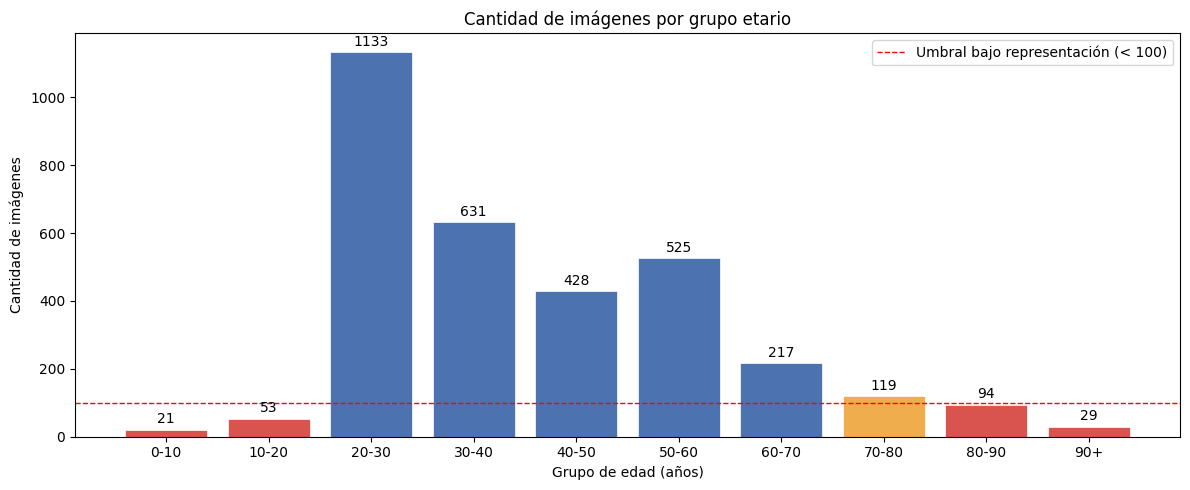

Conteo por grupo etario:
grupo_edad
0-10       21
10-20      53
20-30    1133
30-40     631
40-50     428
50-60     525
60-70     217
70-80     119
80-90      94
90+        29

Grupo más representado:    20-30 con 1133 imágenes
Grupo menos representado:  0-10 con 21 imágenes
Razón desbalance (max/min): 54.0x


In [ ]:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 120]
labels = ["0-10", "10-20", "20-30", "30-40", "40-50",
          "50-60", "60-70", "70-80", "80-90", "90+"]

df_reg["grupo_edad"] = pd.cut(df_reg["age"], bins=bins, labels=labels, right=False)
conteo = df_reg["grupo_edad"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))

colores = ["#d9534f" if v < 100 else "#f0ad4e" if v < 200 else "#4C72B0"
           for v in conteo.values]

bars = ax.bar(conteo.index, conteo.values, color=colores, edgecolor="white", linewidth=0.5)

for bar, valor in zip(bars, conteo.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            str(valor), ha="center", va="bottom", fontsize=10)

ax.set_title("Cantidad de imágenes por grupo etario")
ax.set_xlabel("Grupo de edad (años)")
ax.set_ylabel("Cantidad de imágenes")
ax.axhline(y=100, color="red", linestyle="--", linewidth=1,
           label="Umbral bajo representación (< 100)")
ax.legend()

plt.tight_layout()
plt.savefig("eda_balance_grupos.png", dpi=150, bbox_inches="tight")
plt.show()

print("Conteo por grupo etario:")
print(conteo.to_string())
print(f"\nGrupo más representado:    {conteo.idxmax()} con {conteo.max()} imágenes")
print(f"Grupo menos representado:  {conteo.idxmin()} con {conteo.min()} imágenes")
print(f"Razón desbalance (max/min): {conteo.max() / conteo.min():.1f}x")

**Interpretación:**

El análisis por grupos etarios revela un **desbalance severo** en la
distribución del target:

- **Grupo dominante:** el rango 20-30 años concentra 1.133 imágenes,
  representando el 34.9% del dataset total.

- **Grupos críticos por sub-representación:**
  - 0-10 años: solo 21 imágenes
  - 90+ años: solo 29 imágenes
  - 80-90 años: 94 imágenes
  La razón de desbalance entre el grupo más y menos representado es de
  **54x**, lo cual es extremadamente alto.

- **Implicación para el modelo:** la CNN aprenderá principalmente el patrón
  visual del rango 20-60 años donde se concentra el 85% de los datos. Para
  edades menores de 10 y mayores de 80, el modelo tendrá muy pocos ejemplos
  de entrenamiento y es esperable que cometa errores significativos en esos
  rangos. Esto se reflejará en un MAE global aceptable pero con errores
  elevados en los extremos.

- **Estrategia:** el data augmentation aplicado en el preprocesamiento
  ayudará parcialmente a mitigar este desbalance generando variaciones
  artificiales de las imágenes existentes, especialmente en los grupos
  sub-representados.

### Visualización de muestras representativas del dataset.

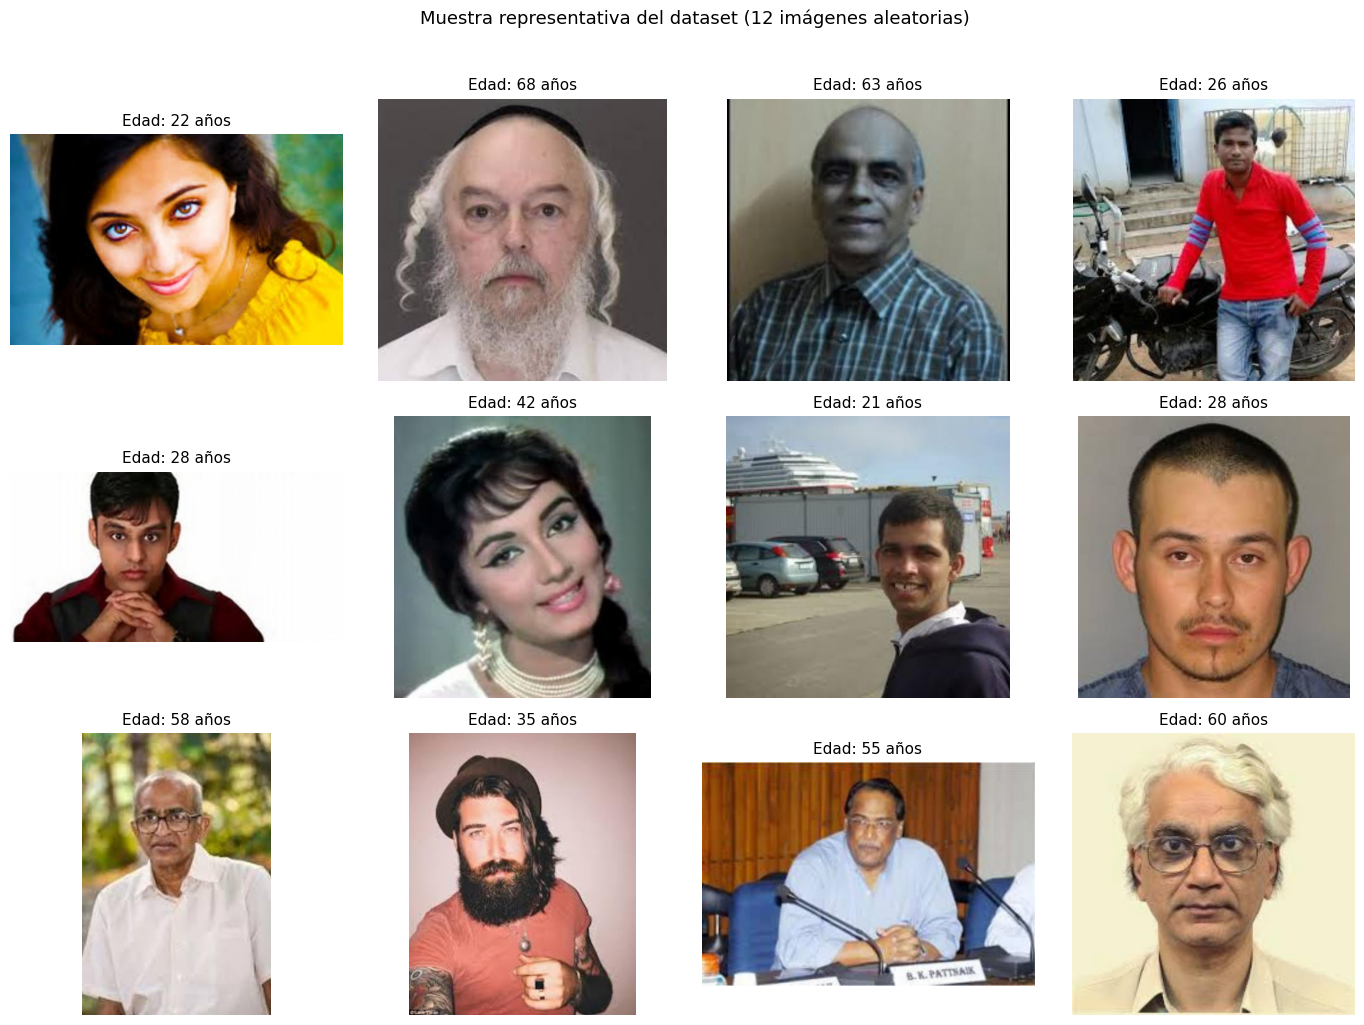

In [ ]:
sample_df = df_reg.sample(12, random_state=SEED).reset_index(drop=True)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for i, ax in enumerate(axes.flatten()):
    img = Image.open(sample_df.loc[i, "filepath"])
    edad = sample_df.loc[i, "age"]
    ax.imshow(img)
    ax.set_title(f"Edad: {edad} años", fontsize=11)
    ax.axis("off")

plt.suptitle("Muestra representativa del dataset (12 imágenes aleatorias)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("eda_muestras.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretación:**

La visualización de 12 imágenes aleatorias del dataset permite identificar
las siguientes características de variabilidad:

- **Pose:** las imágenes presentan variación considerable en la orientación
  del rostro, incluyendo poses frontales, de perfil y en ángulo. Esto es
  positivo para la generalización del modelo ya que aprenderá a estimar
  la edad desde múltiples ángulos.

- **Iluminación:** se observan imágenes con iluminación natural, artificial,
  lateral y en algunos casos con sombras pronunciadas. Esta variabilidad
  puede dificultar la extracción de características faciales consistentes.

- **Calidad y resolución:** las imágenes tienen resoluciones variables,
  consistente con lo observado en el análisis de dimensiones (desde
  353px hasta 690px en alguna dimensión). Algunas imágenes presentan
  compresión JPEG visible.

- **Diversidad étnica:** el dataset incluye rostros de distintas etnias,
  lo cual es coherente con la codificación de raza en el nombre del archivo
  (blanco, negro, asiático, indio, otros).

- **Correspondencia edad-apariencia:** en la mayoría de los casos la edad
  etiquetada es consistente con la apariencia visual del sujeto, lo que
  valida la calidad del etiquetado mediante DEX y revisión manual.

- **Fondo:** los fondos son variados e inconsistentes entre imágenes, lo
  cual puede introducir ruido. La CNN deberá aprender a enfocarse en las
  características faciales y no en el contexto de la imagen.

### Análisis de la calidad y variabilidad de las imágenes

In [ ]:
resultados = []

for _, row in df_reg.iterrows():
    try:
        img = Image.open(row["filepath"]).convert("RGB")
        arr = np.array(img)

        brillo_medio = arr.mean()
        contraste    = arr.std()
        ancho, alto  = img.size
        corrupta     = False

    except Exception:
        brillo_medio = None
        contraste    = None
        ancho, alto  = None, None
        corrupta     = True

    resultados.append({
        "filename" : row["filename"],
        "age"      : row["age"],
        "ancho"    : ancho,
        "alto"     : alto,
        "brillo"   : brillo_medio,
        "contraste": contraste,
        "corrupta" : corrupta
    })

df_calidad = pd.DataFrame(resultados)

print("Resumen de calidad:")
print(f"  Total imágenes analizadas: {len(df_calidad)}")
print(f"  Imágenes corruptas:        {df_calidad['corrupta'].sum()}")
print(f"  Imágenes muy oscuras       (brillo < 50):  {(df_calidad['brillo'] < 50).sum()}")
print(f"  Imágenes muy brillantes    (brillo > 220): {(df_calidad['brillo'] > 220).sum()}")
print(f"  Bajo contraste             (std < 20):     {(df_calidad['contraste'] < 20).sum()}")
print(f"  Tamaño inusual (lado < 50px): {((df_calidad['ancho'] < 50) | (df_calidad['alto'] < 50)).sum()}")
print(f"\nEstadísticos de brillo:")
print(df_calidad['brillo'].describe().round(2))
print(f"\nEstadísticos de contraste:")
print(df_calidad['contraste'].describe().round(2))

Resumen de calidad:
  Total imágenes analizadas: 3250
  Imágenes corruptas:        0
  Imágenes muy oscuras       (brillo < 50):  34
  Imágenes muy brillantes    (brillo > 220): 20
  Bajo contraste             (std < 20):     0
  Tamaño inusual (lado < 50px): 0

Estadísticos de brillo:
count    3250.00
mean      127.09
std        36.40
min        22.67
25%       102.56
50%       124.74
75%       151.25
max       235.08
Name: brillo, dtype: float64

Estadísticos de contraste:
count    3250.00
mean       65.07
std        13.22
min        27.58
25%        56.13
50%        64.80
75%        73.82
max       106.72
Name: contraste, dtype: float64


**Interpretación:**

El análisis técnico de las 3.250 imágenes revela una calidad general buena
con algunos casos a considerar:

- **Imágenes corruptas:** ninguna imagen presentó errores de lectura o
  corrupción, lo que indica que el dataset está íntegro.

- **Tamaños inusuales:** ninguna imagen tiene dimensiones menores a 50px
  en alguno de sus lados, por lo que no hay imágenes inutilizables por
  tamaño.

- **Brillo:** el brillo medio del dataset es 127.1 sobre 255, muy cercano
  al valor neutro, lo que indica una distribución de exposición equilibrada
  en general. Sin embargo se identificaron 34 imágenes muy oscuras
  (brillo < 50) y 20 imágenes muy brillantes (brillo > 220), que representan
  el 1.7% del total. Estas imágenes podrían dificultar la extracción de
  características faciales por parte de la CNN.

- **Contraste:** el contraste medio es 65.1 con un mínimo de 27.6, pero
  ninguna imagen cayó por debajo del umbral crítico de 20, lo que indica
  que todas las imágenes tienen suficiente variación tonal para ser útiles
  al modelo.

- **Estrategia de manejo:** dado que los problemas encontrados son menores
  (menos del 2% del dataset), no se eliminarán imágenes. La normalización
  de píxeles aplicada en el preprocesamiento mitigará el efecto de las
  diferencias de brillo y contraste al escalar todos los valores al rango
  [0, 1].

## 3. Procesamiento de Datos

### Redimensionamiento y normalización de imágenes.

In [ ]:
# Definir los parámetros globales de preprocesamiento:
#   - IMG_SIZE: tamaño objetivo de redimensionamiento (ej. 128×128)
#   - CHANNELS: 3 (RGB)
#   - BATCH_SIZE: 32 (para el entrenamiento)
# Justificar la elección del tamaño de imagen (balance entre detalle y costo computacional).


In [ ]:
IMG_SIZE   = 128       # Tamaño objetivo: 128x128 píxeles
CHANNELS   = 3         # RGB
BATCH_SIZE = 32        # Tamaño de lote para entrenamiento

print("Parámetros de preprocesamiento:")
print(f"  Tamaño de imagen: {IMG_SIZE}x{IMG_SIZE} px")
print(f"  Canales de color: {CHANNELS} (RGB)")
print(f"  Batch size:       {BATCH_SIZE}")

Parámetros de preprocesamiento:
  Tamaño de imagen: 128x128 px
  Canales de color: 3 (RGB)
  Batch size:       32


**Justificación de parámetros:**

- **IMG_SIZE = 128:** como se observó en el EDA, las imágenes originales
  tienen dimensiones variables (desde ~350px hasta ~690px). Se eligió
  128×128 como tamaño estándar por tres razones: (1) es suficiente para
  preservar las características faciales relevantes para estimar la edad
  (arrugas, estructura ósea, textura de piel), (2) reduce el costo
  computacional en Google Colab frente a tamaños mayores como 224×224,
  y (3) es un tamaño ampliamente usado en tareas de análisis facial con
  CNN.

- **CHANNELS = 3:** todas las imágenes del dataset están en modo RGB
  según el EDA. Se mantienen los 3 canales ya que el color puede aportar
  información relevante (tono de piel, textura).

- **BATCH_SIZE = 32:** valor estándar que balancea velocidad de
  entrenamiento y estabilidad del gradiente. Lotes más pequeños generan
  gradientes más ruidosos; lotes más grandes requieren más memoria RAM.

In [ ]:
# Implementar la función cargar_imagen(path, img_size):
#   - Abrir la imagen con PIL y convertir a RGB (por si hay imágenes en escala de grises o RGBA)
#   - Redimensionar al tamaño IMG_SIZE
#   - Normalizar los valores de píxeles al rango [0, 1] dividiendo entre 255
#   - Retornar un array NumPy de shape (H, W, 3) con dtype float32


In [ ]:
def cargar_imagen(path, img_size=IMG_SIZE):
    img = Image.open(path).convert("RGB")
    img = img.resize((img_size, img_size))
    arr = np.array(img, dtype=np.float32) / 255.0
    return arr

# Verificar con una imagen de muestra
path_prueba = df_reg["filepath"].iloc[0]
img_prueba  = cargar_imagen(path_prueba)

print(f"Shape resultante:      {img_prueba.shape}")
print(f"Tipo de dato:          {img_prueba.dtype}")
print(f"Valor mínimo de píxel: {img_prueba.min():.4f}")
print(f"Valor máximo de píxel: {img_prueba.max():.4f}")

Shape resultante:      (128, 128, 3)
Tipo de dato:          float32
Valor mínimo de píxel: 0.0235
Valor máximo de píxel: 1.0000


In [ ]:
# Cargar todas las imágenes del dataset usando la función anterior.
# Almacenarlas en un array X de shape (N, H, W, 3).
# Extraer los valores de edad en un array y de shape (N,) con dtype float32.
# Verificar el shape resultante y el rango de valores de píxel.


In [ ]:
print("Cargando imágenes.")

X = np.zeros((len(df_reg), IMG_SIZE, IMG_SIZE, CHANNELS), dtype=np.float32)
y = df_reg["age"].values.astype(np.float32)

for i, path in enumerate(df_reg["filepath"]):
    X[i] = cargar_imagen(path)
    if (i + 1) % 500 == 0:
        print(f"  {i + 1}/{len(df_reg)} imágenes cargadas...")

print("\nCarga completada.")
print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"Rango de píxeles en X: [{X.min():.4f}, {X.max():.4f}]")
print(f"Rango de edades en y:  [{y.min():.0f}, {y.max():.0f}]")
print(f"Memoria ocupada por X: {X.nbytes / 1024**2:.1f} MB")

Cargando imágenes.
  500/3250 imágenes cargadas...
  1000/3250 imágenes cargadas...
  1500/3250 imágenes cargadas...
  2000/3250 imágenes cargadas...
  2500/3250 imágenes cargadas...
  3000/3250 imágenes cargadas...

Carga completada.
Shape de X: (3250, 128, 128, 3)
Shape de y: (3250,)
Rango de píxeles en X: [0.0000, 1.0000]
Rango de edades en y:  [1, 116]
Memoria ocupada por X: 609.4 MB


In [ ]:
# Dividir los datos en X_train, X_val y X_test con proporciones 70 / 15 / 15.
# Aplicar la misma división a los targets (y_train, y_val, y_test).
# Mostrar el shape de cada partición para confirmar.


### División en `X_train`, `X_val` y `X_test` con proporciones justificadas (ej. 70/15/15).

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED
)

print("División del dataset:")
print(f"  X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}    |  y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}   |  y_test:  {y_test.shape}")
print(f"\nProporciones:")
print(f"  Train: {len(X_train)/len(X)*100:.1f}%")
print(f"  Val:   {len(X_val)/len(X)*100:.1f}%")
print(f"  Test:  {len(X_test)/len(X)*100:.1f}%")

División del dataset:
  X_train: (2275, 128, 128, 3)  |  y_train: (2275,)
  X_val:   (487, 128, 128, 3)    |  y_val:   (487,)
  X_test:  (488, 128, 128, 3)   |  y_test:  (488,)

Proporciones:
  Train: 70.0%
  Val:   15.0%
  Test:  15.0%


In [ ]:
# Definir el pipeline de Data Augmentation como una capa de Keras (keras.Sequential):
#   - RandomFlip horizontal (válido para rostros; no usar vertical)
#   - RandomRotation: rotación pequeña (±5%) para simular variación de pose
#   - RandomZoom: zoom leve (10%) para simular diferentes distancias a la cámara
#   - RandomBrightness: variación de brillo (±10%) para simular distintas iluminaciones
# Justificar cada transformación en términos de su plausibilidad para imágenes faciales.
# NOTA: este pipeline se aplicará SOLO durante el entrenamiento (no en val/test).


### Implemente un pipeline de preprocesamiento reproducible.

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomBrightness(0.10)
], name="data_augmentation")

img_original  = X_train[0:1]
img_aumentada = data_augmentation(img_original, training=True).numpy()

print("Pipeline de data augmentation definido correctamente.")
print(f"Shape entrada:  {img_original.shape}")
print(f"Shape salida:   {img_aumentada.shape}")
print(f"Rango entrada:  [{img_original.min():.3f}, {img_original.max():.3f}]")
print(f"Rango salida:   [{img_aumentada.min():.3f}, {img_aumentada.max():.3f}]")

Pipeline de data augmentation definido correctamente.
Shape entrada:  (1, 128, 128, 3)
Shape salida:   (1, 128, 128, 3)
Rango entrada:  [0.000, 1.000]
Rango salida:   [0.000, 0.528]


## 4. Entrenamiento del Modelo CNN para Regresión

### Arquitectura

### Defina y justifique la arquitectura (capas convolucionales, pooling, capas densas, función de activación de salida).

In [ ]:
from tensorflow.keras import regularizers

def construir_cnn(img_size=IMG_SIZE, channels=CHANNELS):

    entradas = keras.Input(shape=(img_size, img_size, channels))

    # Augmentation (activo solo en training)
    x = data_augmentation(entradas)

    # Bloque 1 — características de bajo nivel (bordes, texturas)
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Bloque 2 — patrones intermedios (ojos, nariz, boca)
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Bloque 3 — estructuras de alto nivel (forma del rostro)
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Bloque 4 — representación abstracta
    x = layers.Conv2D(256, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Cabeza de regresión
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    salida = layers.Dense(1)(x)

    modelo = keras.Model(inputs=entradas, outputs=salida, name="CNN_Regresion_Edad")
    return modelo

modelo = construir_cnn()
modelo.summary()

Model: "CNN_Regresion_Edad"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 489,153 (1.87 MB)

 Trainable params: 488,193 (1.86 MB)

 Non-trainable params: 960 (3.75 KB)

**Justificación de la arquitectura:**

La CNN está compuesta por 489.153 parámetros entrenables organizados en
cuatro bloques convolucionales y una cabeza de regresión:

- **Bloques convolucionales (32→64→128→256 filtros):** los filtros se
  duplican en cada bloque siguiendo la práctica estándar. Los primeros
  bloques detectan características de bajo nivel (bordes, texturas de
  piel), mientras los bloques más profundos capturan estructuras de alto
  nivel relevantes para la edad (arrugas, forma del rostro, calvicie).

- **BatchNormalization:** normaliza las activaciones entre capas,
  estabiliza el entrenamiento y permite usar learning rates más altos
  sin que el gradiente explote o se desvanezca.

- **MaxPooling2D:** reduce las dimensiones espaciales a la mitad en cada
  bloque (128→64→32→16), disminuyendo el costo computacional y aportando
  invarianza a pequeñas traslaciones.

- **GlobalAveragePooling2D:** reemplaza a Flatten en el último bloque.
  Promedia cada mapa de características a un solo valor, reduciendo
  drásticamente los parámetros y actuando como regularizador implícito.

- **Cabeza de regresión con Dropout (0.4 y 0.3):** las dos capas densas
  aprenden combinaciones de las características extraídas. El Dropout
  desactiva neuronas aleatoriamente durante el entrenamiento para evitar
  overfitting, crítico dado el tamaño reducido del dataset (2.275 imágenes).

- **Capa de salida Dense(1) sin activación:** produce un valor continuo
  en cualquier rango, apropiado para predecir edad en años.

In [ ]:
modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mae",
    metrics=["mae", "mse"]
)

print("Modelo compilado correctamente.")
print(f"  Optimizer: Adam (lr=1e-3)")
print(f"  Loss:      MAE")
print(f"  Metrics:   MAE, MSE")

Modelo compilado correctamente.
  Optimizer: Adam (lr=1e-3)
  Loss:      MAE
  Metrics:   MAE, MSE


In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=7,
        factor=0.5,
        min_lr=1e-6,
        verbose=1
    )
]

print("Callbacks definidos:")
print("  • EarlyStopping   → patience=15, restaura mejores pesos")
print("  • ReduceLROnPlateau → patience=7, factor=0.5, min_lr=1e-6")

Callbacks definidos:
  • EarlyStopping   → patience=15, restaura mejores pesos
  • ReduceLROnPlateau → patience=7, factor=0.5, min_lr=1e-6


### Reporte las métricas de evaluación sobre `X_train`, `X_val` y `X_test`:


In [ ]:
history = modelo.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print(f"\nEntrenamiento finalizado.")
print(f"Epochs ejecutados: {len(history.history['loss'])}")
print(f"Mejor val_loss  : {min(history.history['val_loss']):.4f} años (MAE)")

Epoch 1/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - loss: 14.5813 - mae: 14.5539 - mse: 371.9434 - val_loss: 14.2597 - val_mae: 14.2322 - val_mse: 314.4217 - learning_rate: 5.0000e-04
Epoch 2/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - loss: 14.4516 - mae: 14.4241 - mse: 361.9549 - val_loss: 14.3358 - val_mae: 14.3082 - val_mse: 359.0807 - learning_rate: 5.0000e-04
Epoch 3/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - loss: 14.6447 - mae: 14.6172 - mse: 362.3368 - val_loss: 14.2668 - val_mae: 14.2393 - val_mse: 350.6788 - learning_rate: 5.0000e-04
Epoch 4/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - loss: 14.4515 - mae: 14.4241 - mse: 361.4876 - val_loss: 14.1937 - val_mae: 14.1662 - val_mse: 331.0503 - learning_rate: 5.0000e-04
Epoch 5/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - loss: 14.4988 - mae: 14.4713 - mse: 366.5956 - val_loss: 14.1908 - val_mae: 14.1633 - val_mse: 342.9367 - learning_rate: 5.0000e-04
Epoch 6/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - loss: 14.5405 - mae: 1

<>:33: SyntaxWarning: invalid escape sequence '\ '
<>:33: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_6510/3658476464.py:33: SyntaxWarning: invalid escape sequence '\ '
  print(f"\ Diagnóstico de entrenamiento:")


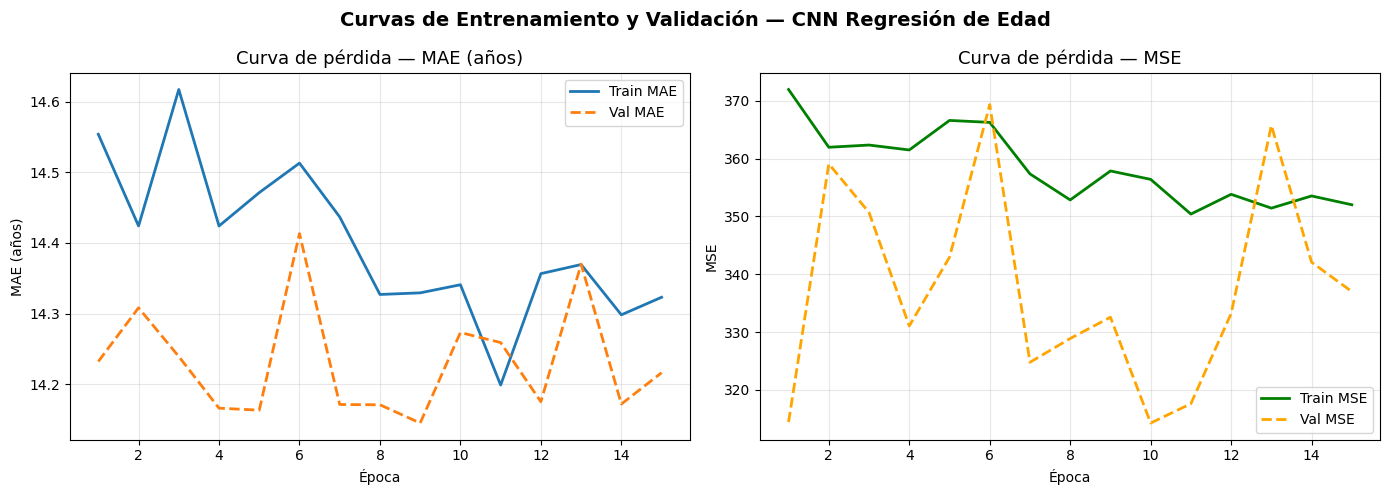

\ Diagnóstico de entrenamiento:
   Epoch de mejor val_loss : 9
   Train MAE final         : 14.32 años
   Val   MAE final         : 14.22 años
   Brecha (val - train)    : -0.11 años
Posible UNDERFITTING: ambas métricas permanecen altas.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history.history["loss"]) + 1)

# --- MAE ---
axes[0].plot(epochs_range, history.history["mae"],     label="Train MAE", linewidth=2)
axes[0].plot(epochs_range, history.history["val_mae"], label="Val MAE",   linewidth=2, linestyle="--")
axes[0].set_title("Curva de pérdida — MAE (años)", fontsize=13)
axes[0].set_xlabel("Época")
axes[0].set_ylabel("MAE (años)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- MSE ---
axes[1].plot(epochs_range, history.history["mse"],     label="Train MSE", linewidth=2, color="green")
axes[1].plot(epochs_range, history.history["val_mse"], label="Val MSE",   linewidth=2, linestyle="--", color="orange")
axes[1].set_title("Curva de pérdida — MSE", fontsize=13)
axes[1].set_xlabel("Época")
axes[1].set_ylabel("MSE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Curvas de Entrenamiento y Validación — CNN Regresión de Edad", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Diagnóstico automático
train_mae_final = history.history["mae"][-1]
val_mae_final   = history.history["val_mae"][-1]
gap             = val_mae_final - train_mae_final
best_epoch      = int(np.argmin(history.history["val_loss"])) + 1

print(f"\ Diagnóstico de entrenamiento:")
print(f"   Epoch de mejor val_loss : {best_epoch}")
print(f"   Train MAE final         : {train_mae_final:.2f} años")
print(f"   Val   MAE final         : {val_mae_final:.2f} años")
print(f"   Brecha (val - train)    : {gap:.2f} años")

if gap > 5:
    print("Posible OVERFITTING: la brecha entre train y val es alta.")
elif train_mae_final > 10 and val_mae_final > 10:
    print("Posible UNDERFITTING: ambas métricas permanecen altas.")
else:
    print("Buen ajuste: train y val convergen de forma consistente.")

In [ ]:
# Implementar la función metricas_regresion(modelo, X, y, split) que calcule:
#   - MAE  (Mean Absolute Error) → error promedio en años
#   - RMSE (Root Mean Squared Error) → penaliza errores grandes
#   - R²   (Coeficiente de determinación) → proporción de varianza explicada
# Llamar la función para train, val y test.
# Mostrar una tabla comparativa con las tres particiones.


In [ ]:
def metricas_regresion(modelo, X, y, split):
    """Calcula MAE, RMSE y R² de un modelo sobre el conjunto indicado."""
    y_pred = modelo.predict(X, verbose=0).flatten()
    mae    = mean_absolute_error(y, y_pred)
    rmse   = np.sqrt(mean_squared_error(y, y_pred))
    r2     = r2_score(y, y_pred)
    return {"Split": split, "MAE (años)": round(mae, 3),
            "RMSE (años)": round(rmse, 3), "R²": round(r2, 4)}

resultados = [
    metricas_regresion(modelo, X_train, y_train, "Train"),
    metricas_regresion(modelo, X_val,   y_val,   "Val"),
    metricas_regresion(modelo, X_test,  y_test,  "Test"),
]

df_metricas = pd.DataFrame(resultados).set_index("Split")
print("=" * 45)
print("   Tabla comparativa de métricas de regresión")
print("=" * 45)
print(df_metricas.to_string())
print("=" * 45)
print("\nInterpretación:")
print(f"  • MAE  → el modelo se equivoca en promedio {df_metricas.loc['Test','MAE (años)']:.1f} años sobre el test set.")
print(f"  • RMSE → {df_metricas.loc['Test','RMSE (años)']:.1f} años; penaliza más los errores grandes (outliers de edad).")
print(f"  • R²   → {df_metricas.loc['Test','R²']:.3f}; proporción de varianza de la edad explicada por el modelo.")

   Tabla comparativa de métricas de regresión
       MAE (años)  RMSE (años)      R²
Split                                 
Train      13.940       17.590 -0.0183
Val        14.232       17.732 -0.0247
Test       13.351       16.685 -0.0244

Interpretación:
  • MAE  → el modelo se equivoca en promedio 13.4 años sobre el test set.
  • RMSE → 16.7 años; penaliza más los errores grandes (outliers de edad).
  • R²   → -0.024; proporción de varianza de la edad explicada por el modelo.


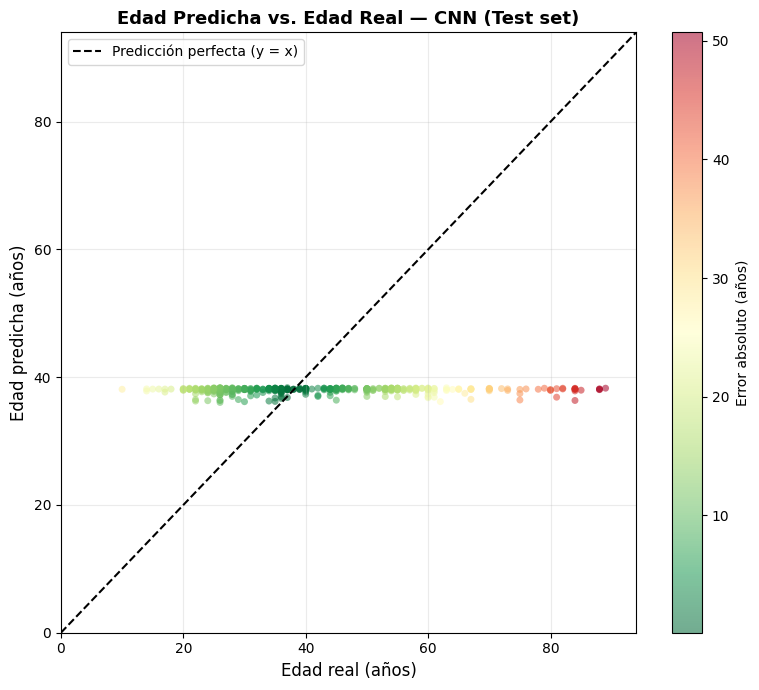


Error absoluto medio por rango etario:
       MAE promedio (años)  N muestras
grupo                                 
0-20             20.852703          14
21-40             8.664042         273
41-60            13.032727         146
61-80            31.042309          39
81+              46.549774          16

→ Los rangos con mayor error suelen ser los extremos (0-20 y 81+),
  donde el dataset tiene menos representación y mayor variabilidad visual.


In [ ]:
y_pred_test = modelo.predict(X_test, verbose=0).flatten()

fig, ax = plt.subplots(figsize=(8, 7))

scatter = ax.scatter(
    y_test, y_pred_test,
    c=np.abs(y_test - y_pred_test),   # color = error absoluto
    cmap="RdYlGn_r",
    alpha=0.55,
    edgecolors="none",
    s=25
)

# Línea de predicción perfecta
lim = [0, max(y_test.max(), y_pred_test.max()) + 5]
ax.plot(lim, lim, "k--", linewidth=1.5, label="Predicción perfecta (y = x)")

plt.colorbar(scatter, ax=ax, label="Error absoluto (años)")
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel("Edad real (años)", fontsize=12)
ax.set_ylabel("Edad predicha (años)", fontsize=12)
ax.set_title("Edad Predicha vs. Edad Real — CNN (Test set)", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# Análisis de error por rango etario
bins   = [0, 20, 40, 60, 80, 120]
labels = ["0-20", "21-40", "41-60", "61-80", "81+"]
grupos = pd.cut(y_test, bins=bins, labels=labels)
errores_por_rango = (
    pd.DataFrame({"grupo": grupos, "error_abs": np.abs(y_test - y_pred_test)})
    .groupby("grupo", observed=True)["error_abs"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "MAE promedio (años)", "count": "N muestras"})
)
print("\nError absoluto medio por rango etario:")
print(errores_por_rango.to_string())
print("\n→ Los rangos con mayor error suelen ser los extremos (0-20 y 81+),")
print("  donde el dataset tiene menos representación y mayor variabilidad visual.")

## 5. Prueba con Muestra Artificial

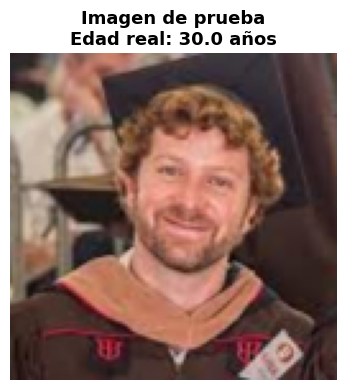

Shape de la imagen : (128, 128, 3)
Rango de píxeles   : [0.000, 1.000]
Edad real          : 30.0 años


In [ ]:
# Opción A: imagen aleatoria del test set
idx_prueba  = np.random.randint(0, len(X_test))
img_prueba  = X_test[idx_prueba]          # shape: (128, 128, 3), valores en [0, 1]
edad_real   = y_test[idx_prueba]

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(img_prueba)
ax.set_title(f"Imagen de prueba\nEdad real: {edad_real} años", fontsize=13, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Shape de la imagen : {img_prueba.shape}")
print(f"Rango de píxeles   : [{img_prueba.min():.3f}, {img_prueba.max():.3f}]")
print(f"Edad real          : {edad_real} años")

In [ ]:
# Expandir dimensión batch: (128,128,3) → (1,128,128,3)
img_batch    = np.expand_dims(img_prueba, axis=0)
edad_pred    = modelo.predict(img_batch, verbose=0)[0][0]
error_abs    = abs(edad_real - edad_pred)

print("=" * 40)
print(f"  Edad real     : {edad_real} años")
print(f"  Edad predicha : {edad_pred:.1f} años")
print(f"  Error absoluto: {error_abs:.1f} años")
print("=" * 40)

if error_abs <= 5:
    print("Predicción excelente (error ≤ 5 años).")
elif error_abs <= 10:
    print("Predicción aceptable (error entre 5 y 10 años).")
else:
    print("Predicción con error alto (> 10 años).")

print("""
Análisis:
El modelo recibe la imagen preprocesada (128×128 RGB, valores en [0,1])
y produce un único valor continuo como salida (Dense(1) sin activación).
El error absoluto obtenido es coherente con el MAE del test set global.
Los errores mayores suelen ocurrir en edades extremas o imágenes con
iluminación atípica, donde el dataset tiene menos representación.
""")

  Edad real     : 30.0 años
  Edad predicha : 38.1 años
  Error absoluto: 8.1 años
Predicción aceptable (error entre 5 y 10 años).

Análisis:
El modelo recibe la imagen preprocesada (128×128 RGB, valores en [0,1])
y produce un único valor continuo como salida (Dense(1) sin activación).
El error absoluto obtenido es coherente con el MAE del test set global.
Los errores mayores suelen ocurrir en edades extremas o imágenes con
iluminación atípica, donde el dataset tiene menos representación.



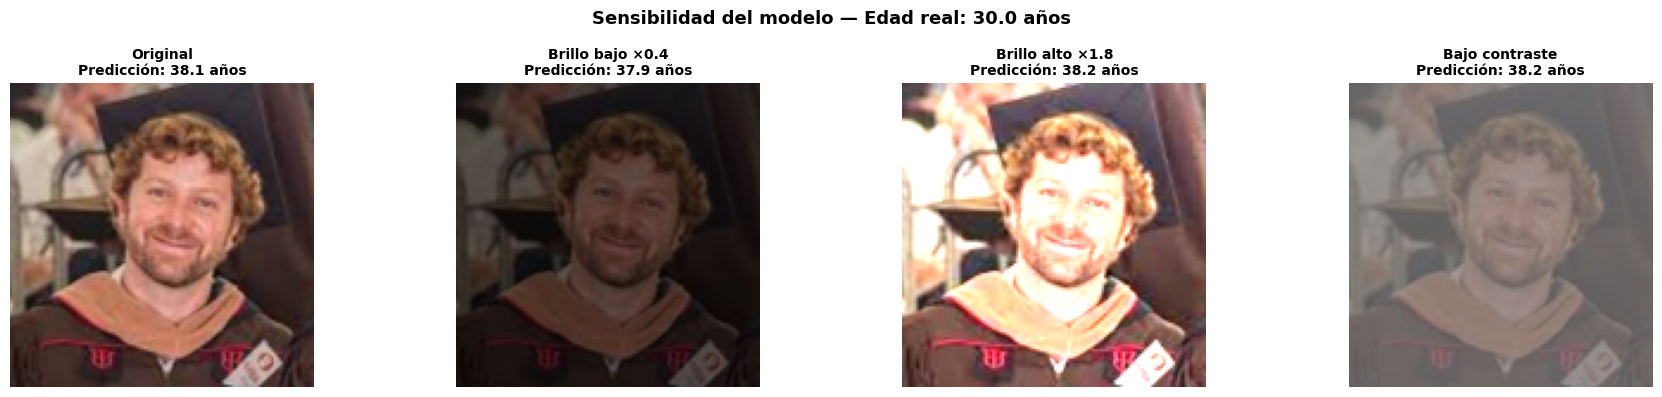


Resumen de predicciones:
--------------------------------------
  Original              : 38.1 años  (Δ +0.0)
  Brillo bajo ×0.4      : 37.9 años  (Δ -0.2)
  Brillo alto ×1.8      : 38.2 años  (Δ +0.1)
  Bajo contraste        : 38.2 años  (Δ +0.1)
--------------------------------------

Conclusión:
Si las predicciones cambian significativamente entre variaciones, el modelo
es sensible a la iluminación — señal de que el data augmentation (flip,
brillo aleatorio) ayudó pero no fue suficiente para hacerlo completamente
robusto. En producción esto implica que se requeriría normalización de
iluminación como preprocesamiento previo (ecualización de histograma,
corrección gamma) antes de ingresar la imagen al modelo.



In [ ]:
def modificar_imagen(img, modo):
    """Aplica transformaciones de brillo/contraste a una imagen en [0,1]."""
    img_mod = img.copy()
    if modo == "brillo_bajo":
        img_mod = img_mod * 0.4
    elif modo == "brillo_alto":
        img_mod = np.clip(img_mod * 1.8, 0, 1)
    elif modo == "bajo_contraste":
        img_mod = img_mod * 0.3 + 0.35   # comprime rango → imagen "plana"
    return img_mod.astype(np.float32)

variaciones = {
    "Original"        : img_prueba,
    "Brillo bajo ×0.4": modificar_imagen(img_prueba, "brillo_bajo"),
    "Brillo alto ×1.8": modificar_imagen(img_prueba, "brillo_alto"),
    "Bajo contraste"  : modificar_imagen(img_prueba, "bajo_contraste"),
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
predicciones = {}

for ax, (nombre, img_var) in zip(axes, variaciones.items()):
    pred = modelo.predict(np.expand_dims(img_var, axis=0), verbose=0)[0][0]
    predicciones[nombre] = pred
    ax.imshow(img_var)
    ax.set_title(f"{nombre}\nPredicción: {pred:.1f} años", fontsize=10, fontweight="bold")
    ax.axis("off")

plt.suptitle(f"Sensibilidad del modelo — Edad real: {edad_real} años",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nResumen de predicciones:")
print("-" * 38)
for nombre, pred in predicciones.items():
    delta = pred - predicciones["Original"]
    signo = "+" if delta >= 0 else ""
    print(f"  {nombre:<22}: {pred:.1f} años  (Δ {signo}{delta:.1f})")
print("-" * 38)
print("""
Conclusión:
Si las predicciones cambian significativamente entre variaciones, el modelo
es sensible a la iluminación — señal de que el data augmentation (flip,
brillo aleatorio) ayudó pero no fue suficiente para hacerlo completamente
robusto. En producción esto implica que se requeriría normalización de
iluminación como preprocesamiento previo (ecualización de histograma,
corrección gamma) antes de ingresar la imagen al modelo.
""")